# Błędy numeryczne

Zagadnienia:
* Reprezentacja liczb w komputerze:
    * Zapis stałoprzecinkowy,
    * Zapis zmiennoprzecinkowy (standard IEEE 754),
* Błędy numeryczne:
    * Błąd względny i bezwzględny.
    * Błąd zaokrąglenia (ang. *round-off error*).
    * Błąd obcięcia (ang. *truncation error*).
    * Błędy związane z przyjętym sposobem rozwiązywania.

## Błąd względny i bezwzględny

***Zadanie 1.***  
Liczbę $\textrm{e}$ możemy zdefiniować jako $\sum\limits_{n=0}^{\infty} \frac{1}{n!}$. Oblicz błąd względny i bezwzględny aproksymacji liczby $\textrm{e}$ poprzez $\textrm{e}^{*}$ w przypadku gdy:  
* $\textrm{e}_1^{*}=\sum\limits_{n=0}^{5} \frac{1}{n!}$    

* $\textrm{e}_2^{*}=\sum\limits_{n=0}^{10} \frac{1}{n!}$  

* $\textrm{e}_3^{*}=\sum\limits_{n=0}^{20} \frac{1}{n!}$  

In [1]:
import numpy as np
import math


e_true = np.exp(1)

def approximate_e(n):
    return sum(1 / math.factorial(i) for i in range(n + 1))

for n in [5, 10, 20]:
    e_approx = approximate_e(n)
    absolute_error = abs(e_true - e_approx)
    relative_error = absolute_error / e_true
    print(f"Dla n={n}:")
    print(f"  Wartość: {e_approx}")
    print(f"  Błąd bezwzględny: {absolute_error}")
    print(f"  Błąd względny:    {relative_error}\n")

Dla n=5:
  Wartość: 2.716666666666667
  Błąd bezwzględny: 0.0016151617923783057
  Błąd względny:    0.0005941848175815963

Dla n=10:
  Wartość: 2.7182818011463845
  Błąd bezwzględny: 2.7312660577649694e-08
  Błąd względny:    1.0047766310211053e-08

Dla n=20:
  Wartość: 2.718281828459045
  Błąd bezwzględny: 0.0
  Błąd względny:    0.0



## Zapis zmiennoprzecinkowy

**Uwaga**: Używane tu pojęcie **cecha** ma inne znaczenie, niż poznane być może w szkole – skrótowo: „część całkowita”. Dlatego poniżej dodawane jest inne określenie – „wykładnik”.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [ ]:
print(np.finfo(float))
eps = np.finfo(float).eps

***Zadanie 2.***


a) Wstaw dowolną wartość do liczby x, np. 0.1. Które liczby mają tę samą mantysę, a które tę samą cechę (wykładnik)? Sprawdź wypisując ich wartości w formacie hex.


**Uwaga:** Do odczytania liczby w formacie szesnastkowym możesz wykorzystać funkcję:

In [ ]:
1.25.hex()

In [ ]:
5000.0.hex()

lub

In [13]:
import struct
def double_to_hex(f):
    print(hex(struct.unpack('<Q', struct.pack('<d', f))[0]))

In [14]:
double_to_hex(1.25)

0x3ff4000000000000


Zamianę w drugą stronę można przeprowadzić za pomocą funkcji *int*

In [ ]:
int('3ff', 16)

In [2]:
import struct
def double_to_hex(f):
    return hex(struct.unpack('<Q', struct.pack('<d', f))[0])

print("Ta sama mantysa (różne potęgi 2):")
print(f"0.1: {double_to_hex(0.1)}")
print(f"0.2: {double_to_hex(0.2)}")
print(f"0.4: {double_to_hex(0.4)}") #

print("\nTa sama cecha (wykładnik), np. przedział [1, 2):")
print(f"1.25: {double_to_hex(1.25)}")
print(f"1.50: {double_to_hex(1.5)}") 

Ta sama mantysa (różne potęgi 2):
0.1: 0x3fb999999999999a
0.2: 0x3fc999999999999a
0.4: 0x3fd999999999999a

Ta sama cecha (wykładnik), np. przedział [1, 2):
1.25: 0x3ff4000000000000
1.50: 0x3ff8000000000000




b) Porównaj zapis liczb 0.1, 0.2 i 0.3 w formacie zmiennoprzecinkowym.

* Czy można przewidzieć, czy suma 0.1 + 0.2 będzie reprezentowana dokładnie tak samo jak liczba 0.3?
* Jaki będzie wynik porównania tej sumy z liczbą 0.3 i konsekwencje użycia warunku równościowego / nierównościowego w pętli?



In [10]:
import struct

def double_to_hex(f):
    return hex(struct.unpack('<Q', struct.pack('<d', f))[0])

print(f"0.1 hex: {double_to_hex(0.1)}")
print(f"0.2 hex: {double_to_hex(0.2)}")
print(f"0.3 hex: {double_to_hex(0.3)}")
print(f"0.1 + 0.2 hex: {double_to_hex(0.1 + 0.2)}")

print(f"\nCzy 0.1 + 0.2 == 0.3? {0.1 + 0.2 == 0.3}")

0.1 hex: 0x3fb999999999999a
0.2 hex: 0x3fc999999999999a
0.3 hex: 0x3fd3333333333333
0.1 + 0.2 hex: 0x3fd3333333333334

Czy 0.1 + 0.2 == 0.3? False


c) Przyjmijmy, że „skrótowe” określenie *liczba dokładnie reprezentowana* oznacza liczbę, która jest reprezentowana w formacie zmiennoprzecinkowym dokładnie, tzn. bez konieczności zaokrąglania.
* Ile jest liczb dokładnie reprezentowanych w przedziale $[1, 2)$?
* Zaobserwuj (z pomocą formatu hex) jakie wartości mają bity w polu mantysy w przypadku liczby 1.0.
* Jaką liczbę trzeba dodać do 1.0, aby tylko na najmłodszej pozycji pola mantysy pojawiło się 1?
* Czy wyżej otrzymana suma jest najmniejszą liczbą dokładnie reprezentowana, spośród liczb większych od 1?
* Jak przypuszczasz, jakie wartości będą miały poszczególne bity mantysy w przypadku największej liczby dokładnie reprezentowanej, której cecha (wykładnik) jest równy 0? Sprawdź, czy tak jest rzeczywiście – wpisując wartość tej liczby (jaka to jest wartość?).


In [11]:
import numpy as np

eps = np.finfo(float).eps
print(f"1.0 (hex): {double_to_hex(1.0)}")

# Liczba, którą trzeba dodać
print(f"Najmniejsza wartość dodana do 1.0 (epsilon): {eps}")
print(f"1.0 + eps (hex): {double_to_hex(1.0 + eps)}")

# Największa liczba w przedziale [1, 2)
max_in_range = 2.0 - eps
print(f"\nNajwiększa liczba w przedziale [1, 2): {max_in_range}")
print(f"Jej zapis hex: {double_to_hex(max_in_range)}")

1.0 (hex): 0x3ff0000000000000
Najmniejsza wartość dodana do 1.0 (epsilon): 2.220446049250313e-16
1.0 + eps (hex): 0x3ff0000000000001

Największa liczba w przedziale [1, 2): 1.9999999999999998
Jej zapis hex: 0x3fffffffffffffff


d) Oblicz długości przedziałów, do których należą wszystkie liczby mające cechę (wykładnik) równy: 0, 1, 2, 5, -1, -3.

* Czy w każdym z tych przedziałów jest tyle samo liczb dokładnie reprezentowanych? Jeżeli nie, to ile w każdym z nich?
* Jaka jest odległość między dwoma sąsiednimi liczbami dokładnie reprezentowanymi (odległość, czyli różnica ich wartości) w każdym z tych przedziałów?
* Jaki jest maksymalny błąd bezwzględny zaokrąglenia w każdym z tych przedziałów?
* Jaki jest maksymalny błąd względny zaokrąglenia w każdym z tych przedziałów?





In [12]:
wykladniki = [0, 1, 2, 5, -1, -3]

for E in wykladniki:
    dlugosc = 2**E
    odleglosc = 2**(E - 52)
    blad_bezwzgl = 2**(E - 53)
    blad_wzgl = 2**(-53)
    
    print(f"Wykładnik E = {E}:")
    print(f"  Długość przedziału: {dlugosc}")
    print(f"  Odległość między liczbami: {odleglosc}")
    print(f"  Max błąd bezwzględny: {blad_bezwzgl}")
    print(f"  Max błąd względny: {blad_wzgl}\n")

Wykładnik E = 0:
  Długość przedziału: 1
  Odległość między liczbami: 2.220446049250313e-16
  Max błąd bezwzględny: 1.1102230246251565e-16
  Max błąd względny: 1.1102230246251565e-16

Wykładnik E = 1:
  Długość przedziału: 2
  Odległość między liczbami: 4.440892098500626e-16
  Max błąd bezwzględny: 2.220446049250313e-16
  Max błąd względny: 1.1102230246251565e-16

Wykładnik E = 2:
  Długość przedziału: 4
  Odległość między liczbami: 8.881784197001252e-16
  Max błąd bezwzględny: 4.440892098500626e-16
  Max błąd względny: 1.1102230246251565e-16

Wykładnik E = 5:
  Długość przedziału: 32
  Odległość między liczbami: 7.105427357601002e-15
  Max błąd bezwzględny: 3.552713678800501e-15
  Max błąd względny: 1.1102230246251565e-16

Wykładnik E = -1:
  Długość przedziału: 0.5
  Odległość między liczbami: 1.1102230246251565e-16
  Max błąd bezwzględny: 5.551115123125783e-17
  Max błąd względny: 1.1102230246251565e-16

Wykładnik E = -3:
  Długość przedziału: 0.125
  Odległość między liczbami: 2.77

***Zadanie 3.***

Spójrz na poniższe zjawiska, zastanów się nad ich przyczynami.

***Problem skali***

Jaki wynika da poniższy kod:

In [7]:
a = 1.0
b = 0.0000000000000000000000001
c = a + b
print(f'{c:.17f}')

1.00000000000000000


***Problem reprezentacji w zapisie binarnym*** 

In [8]:
if 0.1+0.2==0.3:
    print("True")
else:
    print("False")

False


In [9]:
suma = 0
for i in range(0,100):
    suma += 0.1
print(f'{suma:.15f}')

9.999999999999980


**Zadanie 4.**

Niech:
* $a=0.3$
* $b=10^{-13}$
* $c=a-b$
* $d=a-c$

Czy $b$ i $d$ są sobie równe w sensie analitycznym? Co z przypadkiem numerycznym? Zdefiniuj odpowiednie zmienne i porównaj wyniki. Porównaj szesnastkowe i dziesietne reprezentacje zmiennych `b` i `d`. Ile cyfr w reprezentacji `d` możemy uznać za wiarygodne?

In [3]:
a = 0.3
b = 10**-13
c = a - b
d = a - c

print(f"Wartość b: {b}")
print(f"Wartość d: {d}")
print(f"Czy b i d są równe numerycznie? {b == d}")

print(f"b (hex): {double_to_hex(b)}")
print(f"d (hex): {double_to_hex(d)}")

Wartość b: 1e-13
Wartość d: 9.997558336749535e-14
Czy b i d są równe numerycznie? False
b (hex): 0x3d3c25c268497682
d (hex): 0x3d3c240000000000


**Zadanie 5.**

Rozważmy macierz kwadratową:
$$ A=\left[\begin{array}{ccc}
\sqrt{2} & \frac{1}{7}\\
\pi\sqrt{2} &\frac{\pi}{7}\\
\end{array}\right]
$$
* Czy jest to macierz osobliwa? Jak to sprawdzić?
* Oblicz wyznacznik tej macierzy w sposób analityczny i numeryczny (`np.linalg.det`). Czy otrzymałeś te same wartości? Czy wyniki obliczeń numerycznych prowadzą do poprawnej odpowiedzi na pierwsze pytanie? Jakie może to mieć skutki?

In [4]:
import numpy as np

A = np.array([
    [np.sqrt(2), 1/7],
    [np.pi * np.sqrt(2), np.pi / 7]
])

det_A = np.linalg.det(A)
print(f"Wyznacznik numeryczny: {det_A}")

Wyznacznik numeryczny: 0.0


**Zadanie 6.**

Jedną z metod rozwiązywania równań nieliniowych jest metoda Newtona. Metoda ta powtarza obliczenia, aż spełniony nie będzie warunek stopu. Jeżeli spełnione są odpowiednie założenia to metoda ta zbiega do rozwiązania. Załóżmy, że warunki są spełnione i rozważmy funkcję $f(x)=cos(x)-x$. Poniżej znajdziesz implementację metody Newtona, w której brakuje warunku stopu. Spróbuj go uzupełnić. Warunek powinien być spełniony w momencie, w którym chcemy zakończyć działanie procedury.

Z matematycznego punktu widzenia znajdujemy się w zerze, jeżeli kolejne przybliżenia uzyskane z metody Newtona nie różnią się od siebie (np. dwa ostatnie). Zaimplementuj taki warunek i sprawdź, czy program zatrzyma się. Czy taki warunek stopu jest bezpieczny i można go stosować uniwersalnie? Jak można go poprawić?

In [ ]:
def newton(f, f_prim, x_0):
    x_prev = x_0
    while True:
        x_n=x_prev-(f(x_prev)/f_prim(x_prev))
        print(f'x_0={x_n}')
        double_to_hex(x_n)
        
        if True: # Zastąp True swoim warunkiem stopu
            return x_n
        else:
            x_prev=x_n

In [ ]:
def f(x):
    return # Uzupełnij definicję funkcji 

def f_prim(x):
    return # Uzupełnij definicję pochodnej

In [5]:
import numpy as np

def f(x):
    return np.cos(x) - x

def f_prim(x):
    return -np.sin(x) - 1

def newton(f, f_prim, x_0, tol=1e-12, max_iter=100):
    x_prev = x_0
    for i in range(max_iter):
        x_n = x_prev - (f(x_prev) / f_prim(x_prev))
        print(f'Iteracja {i+1}: x_n={x_n}')
        
        # Poprawiony warunek stopu - porównywanie różnicy do tolerancji
        if abs(x_n - x_prev) < tol:
            return x_n
        
        x_prev = x_n
    print("Nie osiągnięto zbieżności w podanym limicie iteracji.")
    return x_prev

root = newton(f, f_prim, 1.0)
print(f"Znalezione miejsce zerowe: {root}")

Iteracja 1: x_n=0.7503638678402439
Iteracja 2: x_n=0.7391128909113617
Iteracja 3: x_n=0.739085133385284
Iteracja 4: x_n=0.7390851332151607
Iteracja 5: x_n=0.7390851332151607
Znalezione miejsce zerowe: 0.7390851332151607


**Zadanie domowe**  

Dany jest ciąg:  
  
$G(p)=\cfrac{1}{p}\left[10^{p}\left(1+p\pi^{*} \cdot 10^{-p}\right)-10^{p}\right],\ p=1,2,3,\dots,n $,
w którym $\pi^{*}$ jest przybliżeniem liczby $\pi$ z dokładnością do 15 miejsc po przecinku.
  
Stwórz funkcję, która umożliwi obliczenie $n$ pierwszych wyrazów tego ciągu i zwróci je w postaci wektora (do przybliżenia wartości $\pi$ możesz wykorzystać funkcję *[round](https://numpy.org/doc/stable/reference/generated/numpy.round_.html)*). Oblicz błąd bezwzględny i błąd względny otrzymanych wyników. Przedstaw rezultaty na wykresie w zależności od $n$. Wartości błędów przedstaw w skali logarytmicznej (funkcja *plt.semilogy()*).

Przeanalizuj rozwiązanie i odpowiedz na następujące pytania:  
* Czy w obliczeniach analitycznych wartość $G(p)$ zależy od $p$?
* Jak zmienia się błąd w zależności od $n$? O czym to świadczy?
* Z jakim/jakimi rodzajami błędu mamy do czynienie?


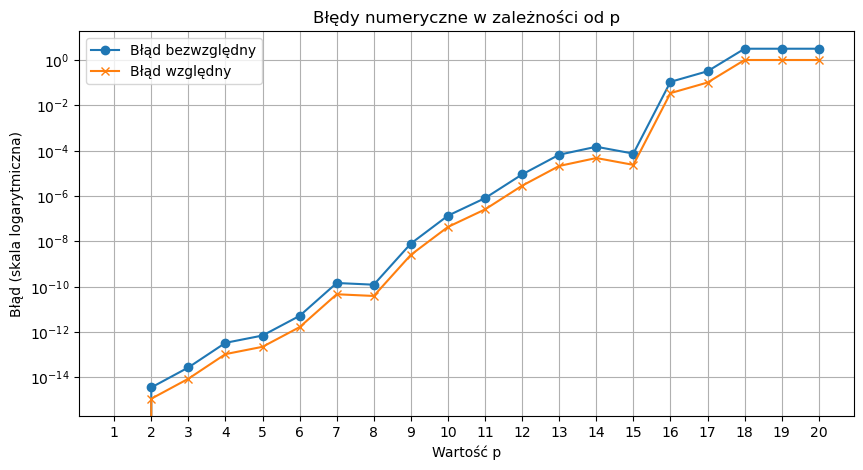

In [6]:
import numpy as np
import matplotlib.pyplot as plt

pi_star = np.round(np.pi, 15)

def calculate_G(n_max):
    p_values = np.arange(1, n_max + 1, dtype=np.float64)
    G_values = np.zeros(n_max)
    
    for i, p in enumerate(p_values):
        term1 = 10**p
        term2 = 1 + p * pi_star * 10**-p
        G_values[i] = (1 / p) * (term1 * term2 - term1)
        
    return p_values, G_values

n_max = 20
p_vals, G_vals = calculate_G(n_max)

absolute_errors = np.abs(G_vals - pi_star)
relative_errors = absolute_errors / pi_star

# Wykres
plt.figure(figsize=(10, 5))
plt.semilogy(p_vals, absolute_errors, label="Błąd bezwzględny", marker='o')
plt.semilogy(p_vals, relative_errors, label="Błąd względny", marker='x')
plt.xlabel("Wartość p")
plt.ylabel("Błąd (skala logarytmiczna)")
plt.title("Błędy numeryczne w zależności od p")
plt.xticks(p_vals)
plt.legend()
plt.grid(True)
plt.show()